In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from pyproj import Transformer

import rioxarray as rxr
from rioxarray.merge import merge_arrays

In [10]:
shore = xr.open_dataset('NC_average_lat_lon.nc')

lon = shore['mean_lon'].values
lat = shore['mean_lat'].values
site = shore['site'].values

Number of shoreline points: 9579
Lon range: -78.5424 to -75.4606
Lat range: 33.8419 to 36.5504


In [11]:
# prepare landsat mosaic
IMG_DIR = Path("imagery")

red_files = [IMG_DIR / f for f in [
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B4.TIF',
    'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B4.TIF',
    'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B4.TIF',
    'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B4.TIF',
]]

green_files = [IMG_DIR / f for f in [
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF',
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B3.TIF',
    'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B3.TIF',
    'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B3.TIF',
]]

blue_files = [IMG_DIR / f for f in [
    'LC08_L2SP_014035_20170409_20200904_02_T1_SR_B2.TIF',
    'LC08_L2SP_014036_20170409_20200904_02_T1_SR_B2.TIF',
    'LC08_L2SP_015036_20170502_20200904_02_T1_SR_B2.TIF',
    'LC08_L2SP_014036_20170527_20200903_02_T1_SR_B2.TIF',
]]

def mosaic_band(file_list):
    """Opens a list of TIFs and merges them into one array."""
    elements = [rxr.open_rasterio(f, masked=True).squeeze() for f in file_list]
    return merge_arrays(elements)

print("Mosaicking bands... ")
merged_red = mosaic_band(red_files)
merged_green = mosaic_band(green_files)
merged_blue = mosaic_band(blue_files)

rgb = xr.concat([merged_red, merged_green, merged_blue], dim='band')
rgb['band'] = [1, 2, 3]

rgb_scaled = (rgb / 20000).clip(0, 1)
print('Done! :)')

Mosaicking bands... 
Done! :)


In [12]:
mosaic_crs = rgb.rio.crs
print("Mosaic CRS:", mosaic_crs)

transformer = Transformer.from_crs("EPSG:4326", mosaic_crs, always_xy=True)
x_proj, y_proj = transformer.transform(lon, lat)

shore = shore.assign(
    x_proj=("site", x_proj),
    y_proj=("site", y_proj),
)

Mosaic CRS: EPSG:32618


In [13]:
sigma = 20  # smoothing window, in units of points

x_smooth = gaussian_filter1d(x_proj, sigma=sigma, mode='nearest')
y_smooth = gaussian_filter1d(y_proj, sigma=sigma, mode='nearest')

mean_spacing = np.mean(np.sqrt(np.diff(x_proj)**2 + np.diff(y_proj)**2))
print(f"Mean point spacing: {mean_spacing:.1f} m")
print(f"Approx. smoothing length scale: {sigma * mean_spacing:.1f} m")

shore = shore.assign(
    x_smooth=("site", x_smooth),
    y_smooth=("site", y_smooth),
)

Mean point spacing: 54.6 m
Approx. smoothing length scale: 1092.9 m


Using

$\kappa = \frac{x' y'' - y' x''}{(x'^2 + y'^2)^{3/2}}$

In [14]:
# cumulative arc length along the smoothed curve
ds = np.sqrt(np.diff(x_smooth)**2 + np.diff(y_smooth)**2)
s = np.concatenate([[0.0], np.cumsum(ds)])

dx = np.gradient(x_smooth, s)
dy = np.gradient(y_smooth, s)
ddx = np.gradient(dx, s)
ddy = np.gradient(dy, s)

curvature = (dx * ddy - dy * ddx) / (dx**2 + dy**2) ** 1.5

shore = shore.assign(curvature=("site", curvature))

Curvature range: -4.25e-04 to 3.08e-03 (1/m)


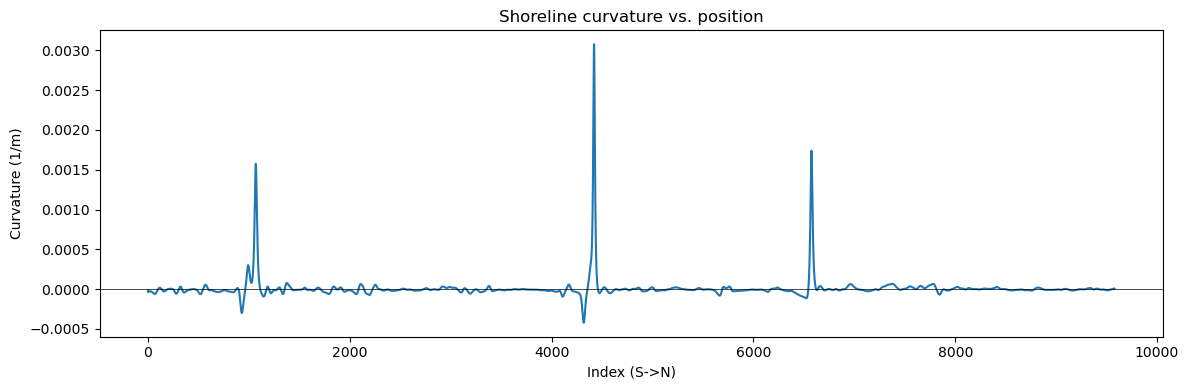

In [21]:
# plot curvature along index
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(curvature)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("Index (S->N)")
ax.set_ylabel("Curvature (1/m)")
ax.set_title("Shoreline curvature vs. position")
plt.tight_layout()
plt.show()

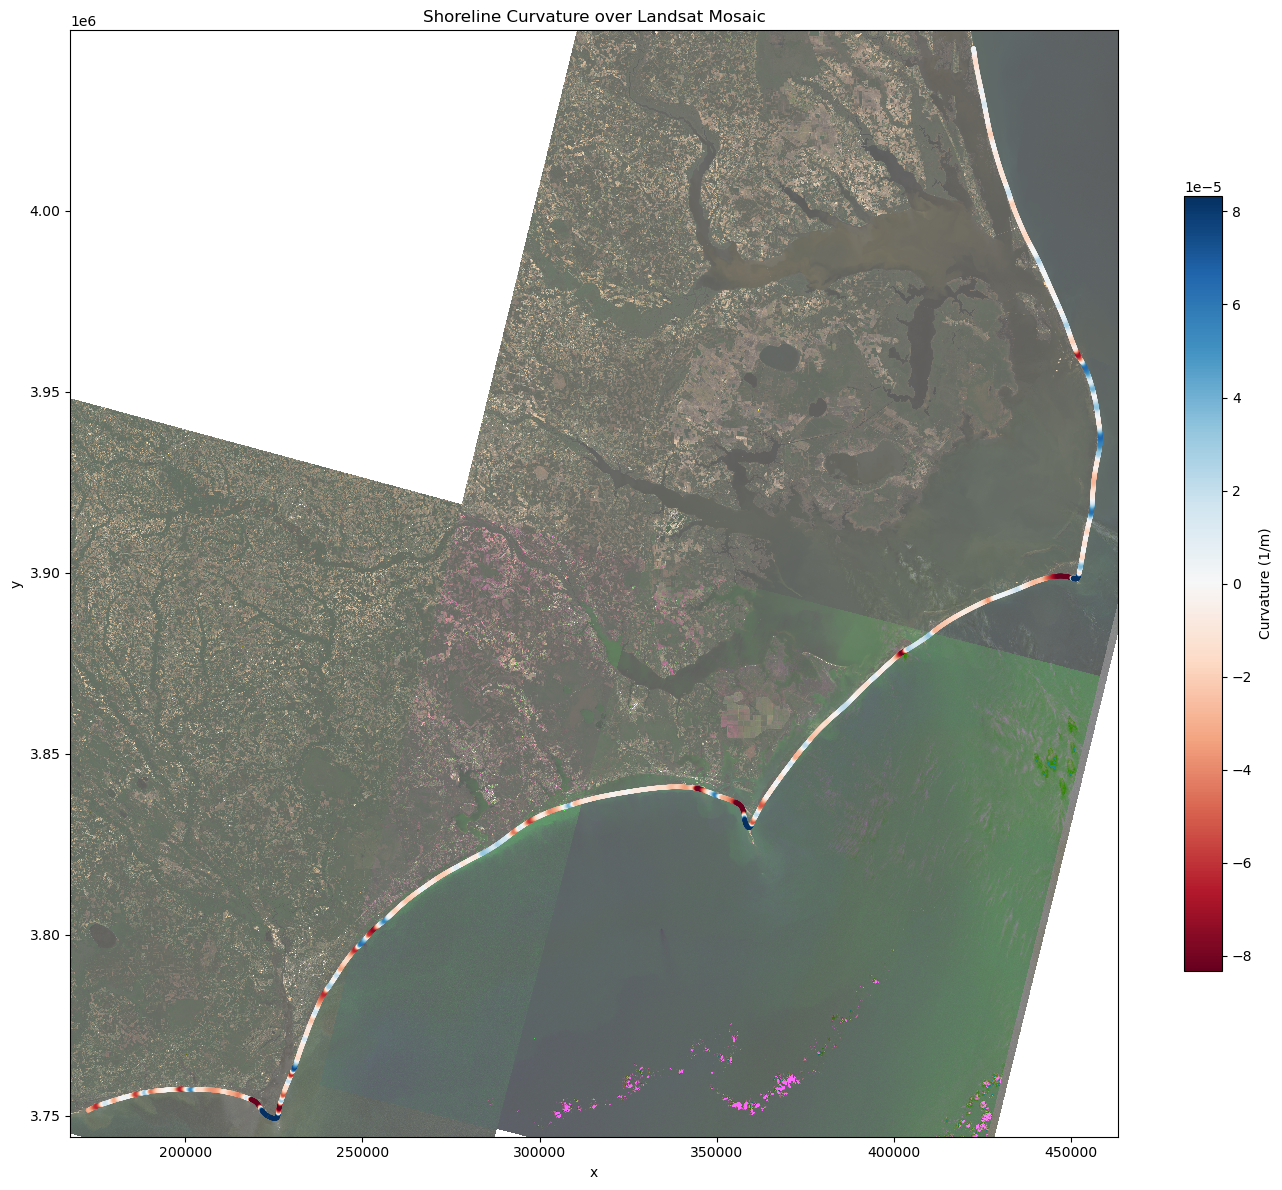

In [19]:
fig, ax = plt.subplots(figsize=(14, 12))

rgb_scaled.plot.imshow(ax=ax)

vmax = np.nanpercentile(np.abs(curvature), 95)
sc = ax.scatter(
    x_smooth, y_smooth,
    c=curvature, cmap='RdBu', vmin=-vmax, vmax=vmax,
    s=10, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Curvature (1/m)', shrink=0.7)

buffer = 5000  # meters; widen/narrow as needed
ax.set_xlim(x_smooth.min() - buffer, x_smooth.max() + buffer)
ax.set_ylim(y_smooth.min() - buffer, y_smooth.max() + buffer)

ax.set_title('Shoreline Curvature over Landsat Mosaic')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

In [ ]:
# optional save to netcdf
out_path = 'NC_average_lat_lon_with_curvature.nc'
shore.to_netcdf(out_path)
print(f"Saved: {out_path}")